In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.models.ensemble import create_ensemble
# CHANGED: Use sklearn metrics directly
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df

paths = load_paths()
logger = setup_logger(level="INFO")

# 1. Create and Evaluate the Ensemble
# This assumes that XGBoost, LightGBM, and CatBoost have already been trained
# and their preds.parquet files exist in artifacts/
logger.info("Creating and Evaluating Ensemble...")
ens_res = create_ensemble(paths=paths, ensemble_yaml=paths.configs_dir / "ensemble.yaml")
print_metrics_summary(ens_res.metrics)

# NOTE: Calibration is now handled INSIDE create_ensemble.
# The output parquet contains 'p_calib' directly.
df_preds = pd.read_parquet(ens_res.preds_path)
# No need to alias p_raw -> p_calib, as p_calib already exists.

# --- Ensure 'dataset' column exists for evaluation ---
if "dataset" not in df_preds.columns:
    logger.info("Merging 'dataset' column from features into predictions...")
    # Load feature files to get flow_id -> dataset mapping
    try:
        vnat_feats = pd.read_parquet(paths.data_processed / "vnat" / "features.parquet", columns=["flow_id"])
        vnat_feats["dataset"] = "vnat"

        iscx_feats = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet", columns=["flow_id"])
        iscx_feats["dataset"] = "iscx"

        df_mapping = pd.concat([vnat_feats, iscx_feats], ignore_index=True)

        # Merge
        df_preds = pd.merge(df_preds, df_mapping, on="flow_id", how="left")

        # Check for missing
        if df_preds["dataset"].isna().any():
            logger.warning(f"Found {df_preds['dataset'].isna().sum()} rows with missing dataset after merge.")
            df_preds["dataset"] = df_preds["dataset"].fillna("unknown")

    except Exception as e:
        logger.error(f"Failed to load features for dataset mapping: {e}")
        # Fallback: try to infer from capture_id if available
        if "capture_id" in df_preds.columns:
             # This is a heuristic, might not be perfect if capture names overlap (unlikely)
             # But we don't have the prefix logic here easily.
             # Let's assume we can't do per-dataset eval if this fails.
             pass


2026-03-05 12:59:45 | INFO | ai-vpn-firewall | Creating and Evaluating Ensemble...
Ensemble Weights: {'xgb': 0.3333333333333333, 'lgbm': 0.3333333333333333, 'catboost': 0.3333333333333333}
Calibrating Ensemble...

EVALUATION SUMMARY
Global Threshold: 0.5

--- Raw Probabilities ---

Split: TRAIN
  N: 14260 (Pos: 2325, Neg: 11935)
  ROC AUC: 0.9999592776283723
  PR AUC:  0.9997951039294419
  At Firewall Threshold 0.9329:
    Precision: 1.0
    Recall:    0.9131182795698924
    F1 Score:  0.9545863309352518
    Confusion Matrix: TN=11935, FP=0, FN=202, TP=2123
  At Monitor Threshold (FPR ~1%) 0.8389:
    Recall: 0.9780645161290322
    Confusion Matrix: TN=11931, FP=4, FN=51, TP=2274

Split: VAL
  N: 3217 (Pos: 746, Neg: 2471)
  ROC AUC: 0.9921968833102054
  PR AUC:  0.9819558873496671
  At Firewall Threshold 0.9329:
    Precision: 0.9969135802469136
    Recall:    0.8659517426273459
    F1 Score:  0.926829268292683
    Confusion Matrix: TN=2469, FP=2, FN=100, TP=646
  At Monitor Threshold

In [2]:
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (ENSEMBLE)")
print("="*60)

metrics = ens_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

T_BLOCK = metrics["policy_thresholds"]["fpr_0_1pct"]["threshold"]
T_MONITOR = metrics["policy_thresholds"]["fpr_1pct"]["threshold"]

print(f"Global Policy Thresholds (from VAL set on Ensemble):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")

# Flow-Level
print("\n--- [1] Flow-Level Triage Performance (on TEST set) ---")
y_true = test_preds["label"]
p_calib = test_preds["p_calib"]

for name, thr in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
    y_hat = (p_calib >= thr).astype(int)
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
    _, fp, _, _ = confusion_matrix(y_true, y_hat).ravel()
    print(f"\n{name} ZONE:")
    print(f"  Recall: {rec:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  False Positives: {fp}")

# Session-Level
print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
session_df = test_preds.groupby("capture_id").agg(
    session_score=("p_calib", "max"),
    session_label=("label", "max")
).reset_index()

y_true_sess = session_df["session_label"]
p_sess = session_df["session_score"]
y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
prec_sess, rec_sess, _, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
_, fp_s, _, _ = confusion_matrix(y_true_sess, y_hat_sess_block).ravel()

print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
print(f"  - Recall:    {rec_sess:.4f}")
print(f"  - Precision: {prec_sess:.4f}")
print(f"  - False Positive Sessions: {fp_s}")

# Voipbuster Case Study
print("\n--- [3] Voipbuster Case Study ---")
vb_mask = test_preds["capture_id"].str.contains("voipbuster")
if vb_mask.any():
    max_prob_vb = test_preds[vb_mask]["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")
    if max_prob_vb >= T_BLOCK: print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR: print("  - RESULT: FLAGGED for monitoring.")
    else: print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the rebalanced test set.")
print("\n" + "="*60)

# --- Per-Dataset Thresholds and Evaluation ---
print("\n--- Per-Dataset Thresholds and Evaluation ---")

if "dataset" in df_preds.columns:
    # 1. Compute Thresholds on VAL (Per Dataset)
    val_preds = df_preds[df_preds["split"] == "val"].copy()
    val_vnat = val_preds[val_preds["dataset"] == "vnat"]
    val_iscx = val_preds[val_preds["dataset"] == "iscx"]

    def get_thresholds(df, label_col="label", prob_col="p_calib"):
        if df.empty: return {}
        fprs = [0.001, 0.01]
        thresholds = {}
        y_true = df[label_col].values
        y_score = df[prob_col].values
        desc_score_indices = np.argsort(y_score, kind="mergesort")[::-1]
        y_score = y_score[desc_score_indices]
        y_true = y_true[desc_score_indices]
        distinct_value_indices = np.where(np.diff(y_score))[0]
        threshold_idxs = np.r_[distinct_value_indices, y_true.size - 1]
        tps = np.cumsum(y_true)[threshold_idxs]
        fps = 1 + threshold_idxs - tps
        fpr_values = fps / fps[-1]
        for target_fpr in fprs:
            idx = np.searchsorted(fpr_values, target_fpr, side='right') - 1
            if idx < 0: idx = 0
            thr = y_score[threshold_idxs[idx]]
            thresholds[f"fpr_{target_fpr}"] = thr
        return thresholds

    thr_vnat = get_thresholds(val_vnat)
    thr_iscx = get_thresholds(val_iscx)

    print(f"  VNAT Thresholds: {thr_vnat}")
    print(f"  ISCX Thresholds: {thr_iscx}")

    # 2. Evaluate on TEST (Per Dataset) using Domain-Specific Thresholds
    test_vnat = test_preds[test_preds["dataset"] == "vnat"]
    test_iscx = test_preds[test_preds["dataset"] == "iscx"]

    for name, df_test, thr_dict in [("VNAT", test_vnat, thr_vnat), ("ISCX", test_iscx, thr_iscx)]:
        print(f"\n--- {name} TEST Performance (using {name} thresholds) ---")
        if df_test.empty:
            print("No test data.")
            continue

        y_true = df_test["label"]
        p_calib = df_test["p_calib"]

        auc = skm.roc_auc_score(y_true, p_calib)
        ap = skm.average_precision_score(y_true, p_calib)
        print(f"ROC AUC: {auc:.4f}")
        print(f"PR AUC:  {ap:.4f}")

        t_block = thr_dict.get("fpr_0.001", 0.99)
        t_monitor = thr_dict.get("fpr_0.01", 0.90)

        for zone, t in [("BLOCK", t_block), ("MONITOR", t_monitor)]:
            y_hat = (p_calib >= t).astype(int)
            prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
            _, fp, _, _ = confusion_matrix(y_true, y_hat).ravel()
            print(f"{zone} (p >= {t:.4f}): Recall={rec:.4f}, Precision={prec:.4f}, FP={fp}")
else:
    print("WARNING: 'dataset' column missing. Skipping per-dataset evaluation.")

print("\n" + "="*60)



ADVANCED FIREWALL EVALUATION (ENSEMBLE)
Global Policy Thresholds (from VAL set on Ensemble):
  - BLOCK:   p >= 0.9329 (Target FPR: 0.1%)
  - MONITOR: p >= 0.8389 (Target FPR: 1%)

--- [1] Flow-Level Triage Performance (on TEST set) ---

BLOCK ZONE:
  Recall: 0.4634
  Precision: 1.0000
  False Positives: 0

MONITOR ZONE:
  Recall: 0.6138
  Precision: 0.9869
  False Positives: 2

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    0.7500
  - Precision: 1.0000
  - False Positive Sessions: 0

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 0.9443
  - RESULT: BLOCKED at the session level.


--- Per-Dataset Thresholds and Evaluation ---
  VNAT Thresholds: {'fpr_0.001': np.float64(0.9379539573309283), 'fpr_0.01': np.float64(0.9284262846286016)}
  ISCX Thresholds: {'fpr_0.001': np.float64(0.8094396788658649), 'fpr_0.01': np.float64(0.3273801816886438)}

--- VNAT TEST Performance (using VNAT thresholds) ---
ROC AU


--- Generating Plots for Ensemble ---


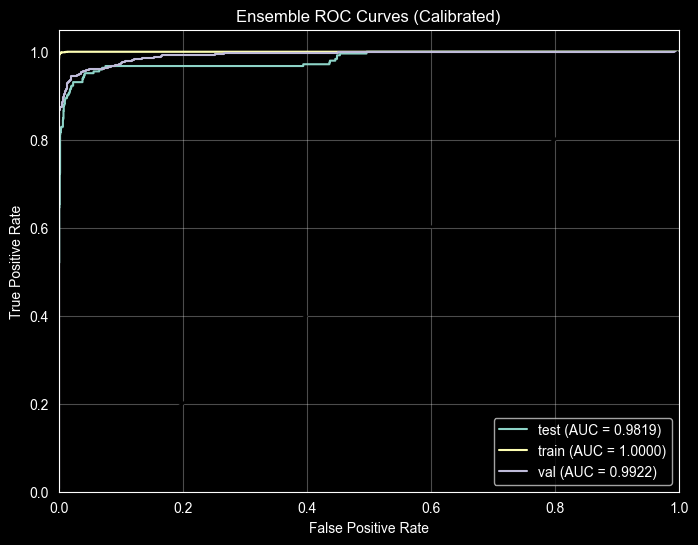

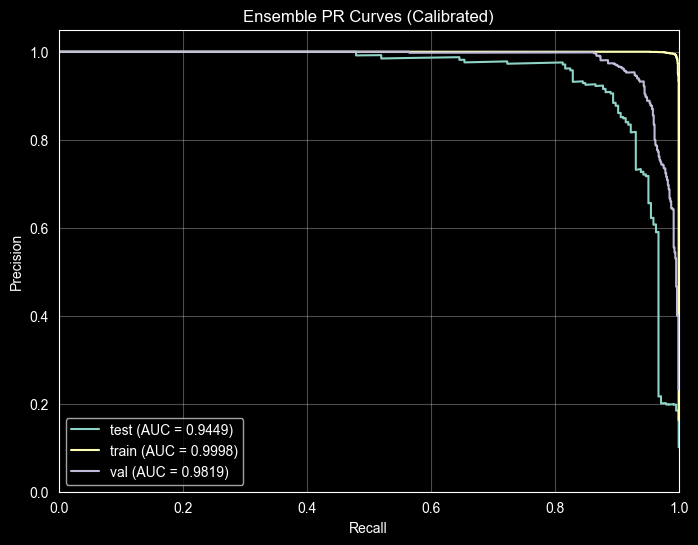

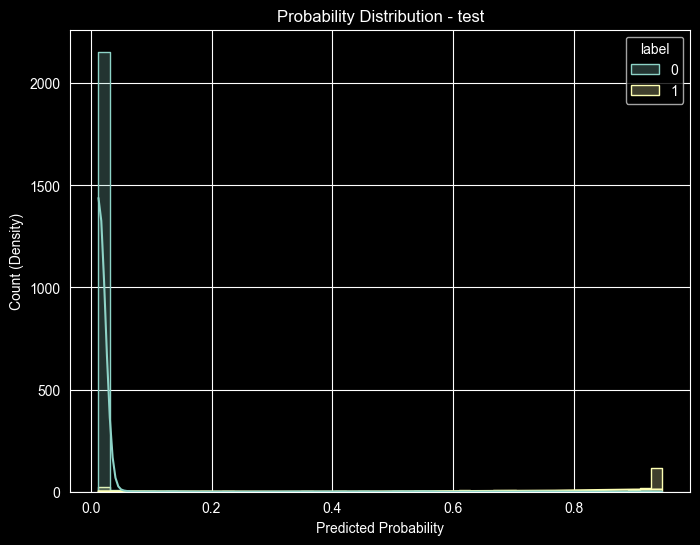

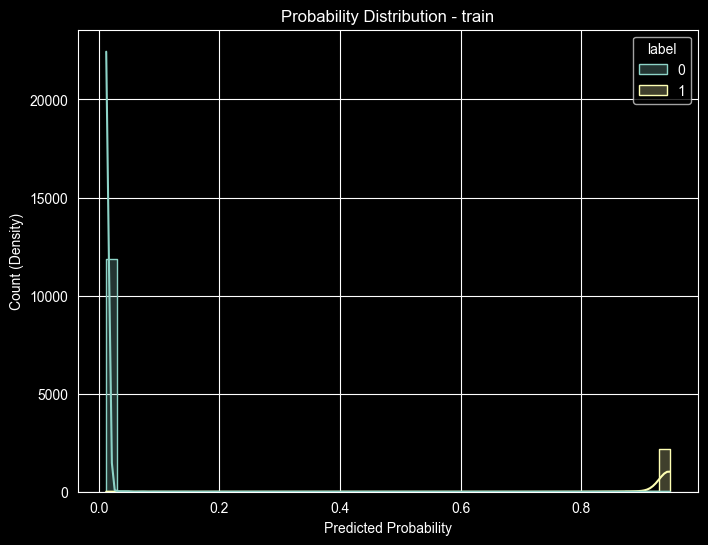

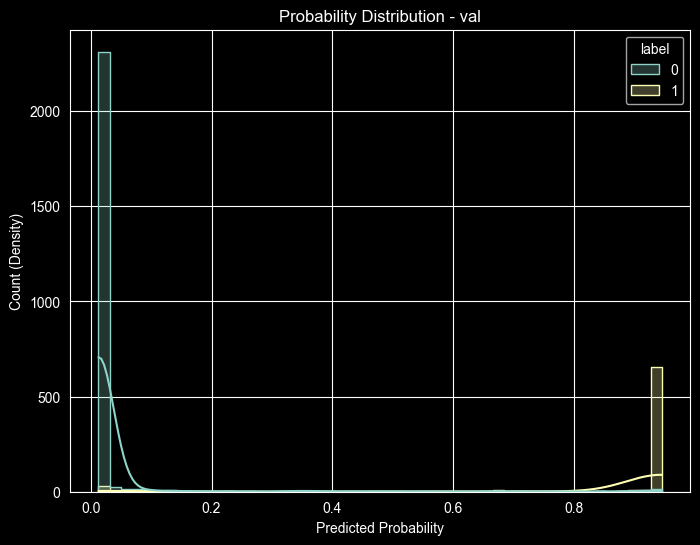

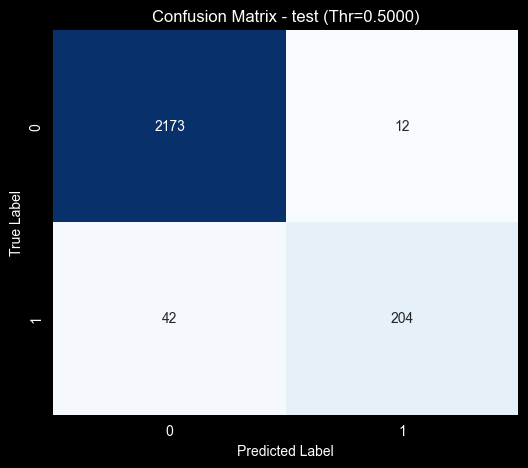

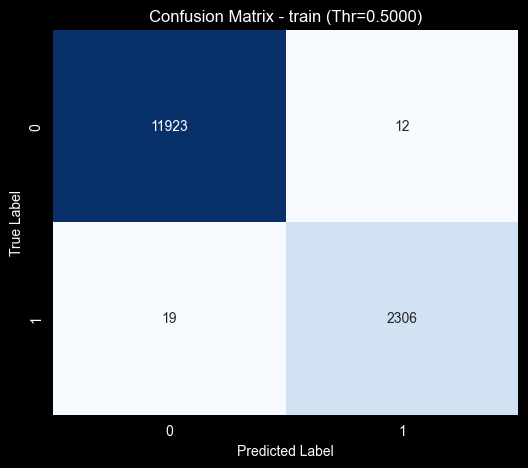

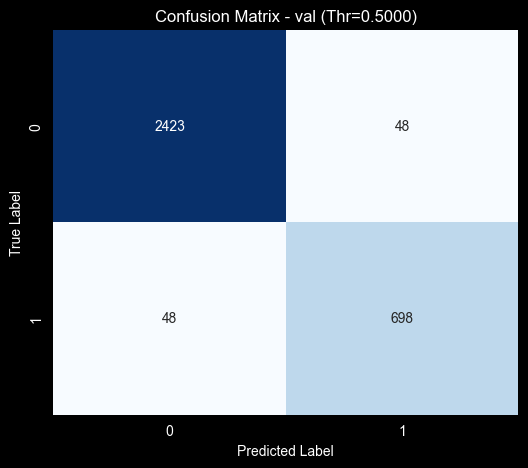


--- Confusion Matrices at Policy Thresholds ---


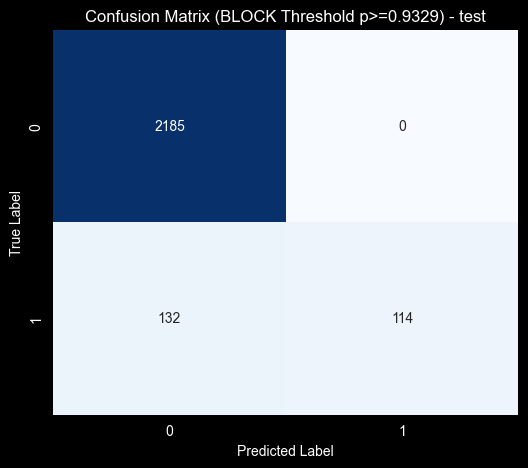

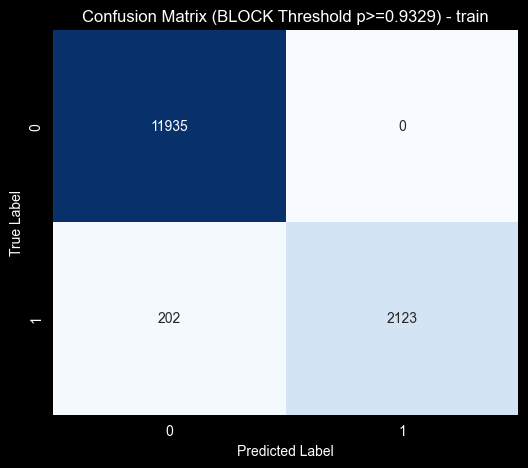

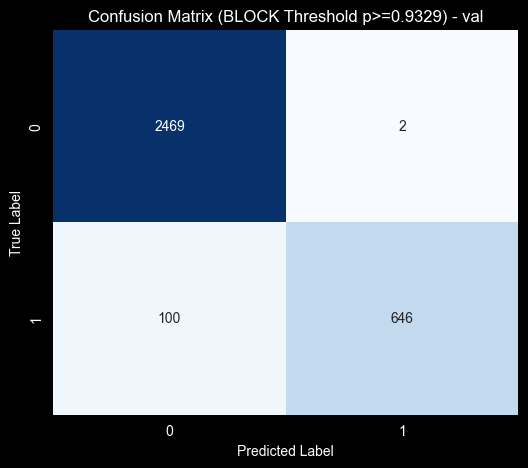

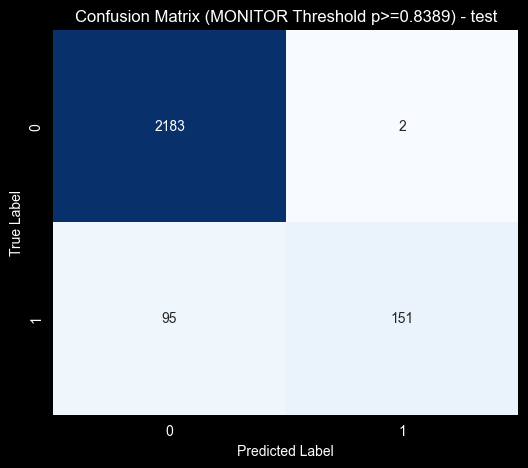

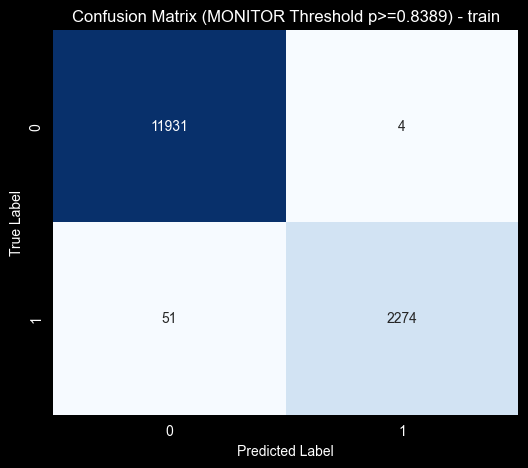

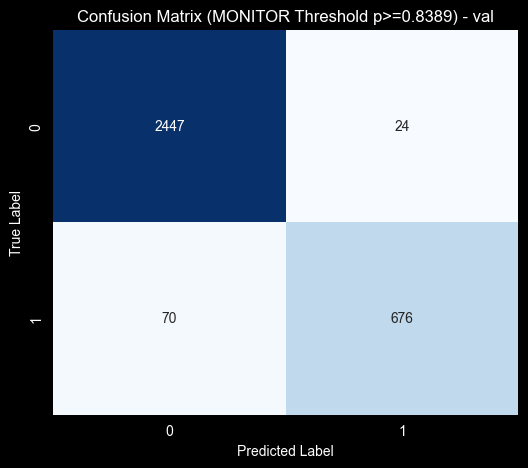

In [3]:
# 4. Visualization
print("\n--- Generating Plots for Ensemble ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)

# NEW: Confusion Matrices for BLOCK and MONITOR thresholds
if "dataset" in df_preds.columns:
    # Use global thresholds from metrics if per-dataset ones aren't computed here (or use VNAT ones as baseline)
    # For simplicity in plots, we use the global ones from metrics
    print("\n--- Confusion Matrices at Policy Thresholds ---")
    plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=T_BLOCK, title=f"Confusion Matrix (BLOCK Threshold p>={T_BLOCK:.4f})")
    plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=T_MONITOR, title=f"Confusion Matrix (MONITOR Threshold p>={T_MONITOR:.4f})")
